In [106]:
from imports import *

In [107]:
result_list = glob.glob("stats/pi*")

print("Number of tested combinations: {}".format(len(result_list)))

Number of tested combinations: 8


In [108]:
def get_instance_name(file_name):
    # Get only the file name

    # Extract the instance name between "pi-" and "--mtr-"
    instance_name = file_name.split("pi-")[-1].split("--mtr-")[0]

    return instance_name


def get_params(file_name):

    params = []
    keys = []

    for key_value in file_name.split("--")[1:]:

        key, value = key_value.split("-")
        if key == "mtm":
            params.append(value)

        elif key == "pop":
            params.append(int(value))

        else:
            params.append(float(value))

        keys.append(key)

    return keys, params


def get_routes(raw_line):
    route, viable = raw_line.split("route: ")[-1].split(";viable: ")

    return [int(str_rt) for str_rt in route.split(",")[:-1]], int(viable)


def get_mean_std(raw_line):
    mean = float(raw_line.split("\t ")[0].split("Mean ")[1])
    std = float(raw_line.split("\t ")[1].split("\tStd Dev ")[1])

    return mean, std


def get_min(raw_line):
    return float(raw_line.split("Min: ")[-1])

def get_max(raw_line):
    return float(raw_line.split("Max: ")[-1])

In [109]:
results = {}

for j, file in enumerate(result_list):

    file_name = file.split("stats/")[-1].split(".txt")[0]

    instance_name = get_instance_name(file_name)

    if instance_name not in results.keys():
        results[instance_name] = {}

    results[instance_name][j] = {
        "file_name": "",
        "routes": [],
        "r_fit": [],
        "best_routes": [],
        "mean_fit": [],
        "viable": [],
        "viable_pct": 0,
        "mtr": 0,
        "cor": 0,
        "mtm": 0,
        "stp": 0,
        "pop": 0,
        "std_fit": 0,
        "max_fit": 0,
        "min_fit": 0,
    }

    results[instance_name][j]["file_name"] = file_name

    params_keys, params_values = get_params(file_name)

    for k, v in zip(params_keys, params_values):
        results[instance_name][j][k] = v

    with open(file, "r", encoding="utf-8") as file:

        for i, raw_line in enumerate(file):

            if i < 20:
                route, viable = get_routes(raw_line)
                results[instance_name][j]["routes"].append(route)
                results[instance_name][j]["viable"].append(viable)

            elif i < 40:
                results[instance_name][j]["r_fit"].append(float(raw_line))

            elif i == 40:
                (
                    results[instance_name][j]["mean_fit"],
                    results[instance_name][j]["std_fit"],
                ) = get_mean_std(raw_line)
                
            elif i == 41:
                results[instance_name][j]["min_fit"] = get_min(raw_line)

            elif i == 42:
                results[instance_name][j]["max_fit"] = get_max(raw_line) 

        results[instance_name][j]["r_fit"] = np.array(
            results[instance_name][j]["r_fit"]
        )

        results[instance_name][j]["best_routes"] = np.argsort(
            results[instance_name][j]["r_fit"]
        )[:3].tolist()

        results[instance_name][j]["viable_pct"] = sum(results[instance_name][j]["viable"])/20*100

In [110]:

# ============================================================
# MANN-WHITNEY TEST
# ============================================================

alpha = 0.05


for instance_name, instance_results in results.items():

    print("\n========================================")
    print(f"INSTANCE: {instance_name}")
    print("========================================")

    # --------------------------------------------------------
    # Find the best parameter combination
    # --------------------------------------------------------

    best_key = min(
        instance_results,
        key=lambda key: instance_results[key]["mean_fit"]
    )

    best_result = instance_results[best_key]

    best_fitness = np.asarray(
        best_result["r_fit"],
        dtype=float
    )

    print(
        f"Best configuration: {best_result['file_name']}"
    )

    print(
        f"Best mean fitness: {best_result['mean_fit']:.6f}"
    )

    # Number of comparisons performed for this instance
    number_of_comparisons = (
        len(instance_results) - 1
    )

    # --------------------------------------------------------
    # Compare every configuration against the best one
    # --------------------------------------------------------

    for key, data in instance_results.items():

        current_fitness = np.asarray(
            data["r_fit"],
            dtype=float
        )

        # ----------------------------------------------------
        # Best configuration
        # ----------------------------------------------------

        if key == best_key:

            data["mann_whitney_U"] = np.nan
            data["p_value"] = np.nan
            data["p_adjusted"] = np.nan
            data["statistical_result"] = "Best configuration"

            continue

        # ----------------------------------------------------
        # Mann-Whitney U test
        # ----------------------------------------------------

        statistic, p_value = mannwhitneyu(
            current_fitness,
            best_fitness,
            alternative="two-sided",
            method="auto"
        )

        # ----------------------------------------------------
        # Bonferroni correction
        # ----------------------------------------------------

        p_adjusted = min(
            p_value * number_of_comparisons,
            1.0
        )

        # ----------------------------------------------------
        # Interpretation
        # ----------------------------------------------------

        if p_adjusted < alpha:

            if np.median(current_fitness) > np.median(best_fitness):

                conclusion = "Statistically worse"

            elif np.median(current_fitness) < np.median(best_fitness):

                conclusion = "Statistically better"

            else:

                conclusion = "Statistically different"

        else:

            conclusion = "No significant difference"

        # ----------------------------------------------------
        # Store test results directly in the results dictionary
        # ----------------------------------------------------

        data["mann_whitney_U"] = statistic
        data["p_value"] = p_value
        data["p_adjusted"] = p_adjusted
        data["statistical_result"] = conclusion


INSTANCE: E-n76-k7.evrp
Best configuration: pi-E-n76-k7.evrp--mtr-0.800000--cor-0.700000--mtm-mix--stp-1.500000--pop-8
Best mean fitness: 830.601428

INSTANCE: E-n22-k4.evrp
Best configuration: pi-E-n22-k4.evrp--mtr-0.800000--cor-0.700000--mtm-inv--stp-1.500000--pop-8
Best mean fitness: 389.059803



Instance: E-n76-k7.evrp

Best parameter combination:
mtr: 0.8
cor: 0.7
mtm: mix
stp: 1.5
pop: 8

Mean fitness: 830.601428
Std fitness:  46.784326
Min fitness:  764.483175
Max fitness:  922.541051

Three best runs:
1º | Run: 7 | Fitness: 764.480000
2º | Run: 11 | Fitness: 765.190000
3º | Run: 2 | Fitness: 774.100000


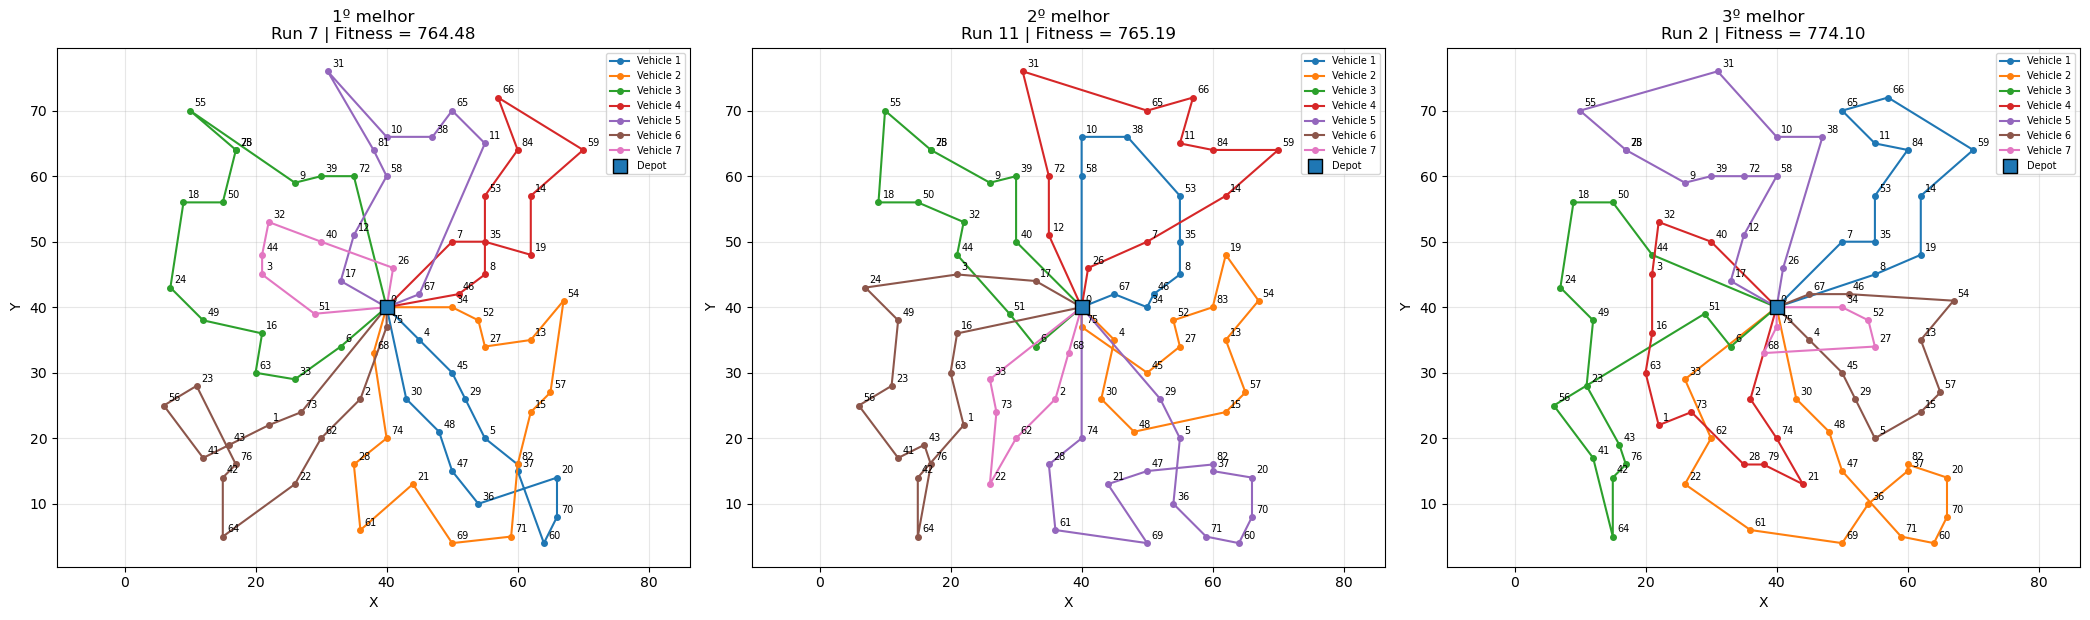


Figure saved at: route_plots/top_3_routes_E-n76-k7.png

Instance: E-n22-k4.evrp

Best parameter combination:
mtr: 0.8
cor: 0.7
mtm: inv
stp: 1.5
pop: 8

Mean fitness: 389.059803
Std fitness:  5.812892
Min fitness:  385.441756
Max fitness:  404.841113

Three best runs:
1º | Run: 4 | Fitness: 385.440000
2º | Run: 3 | Fitness: 385.440000
3º | Run: 8 | Fitness: 385.440000


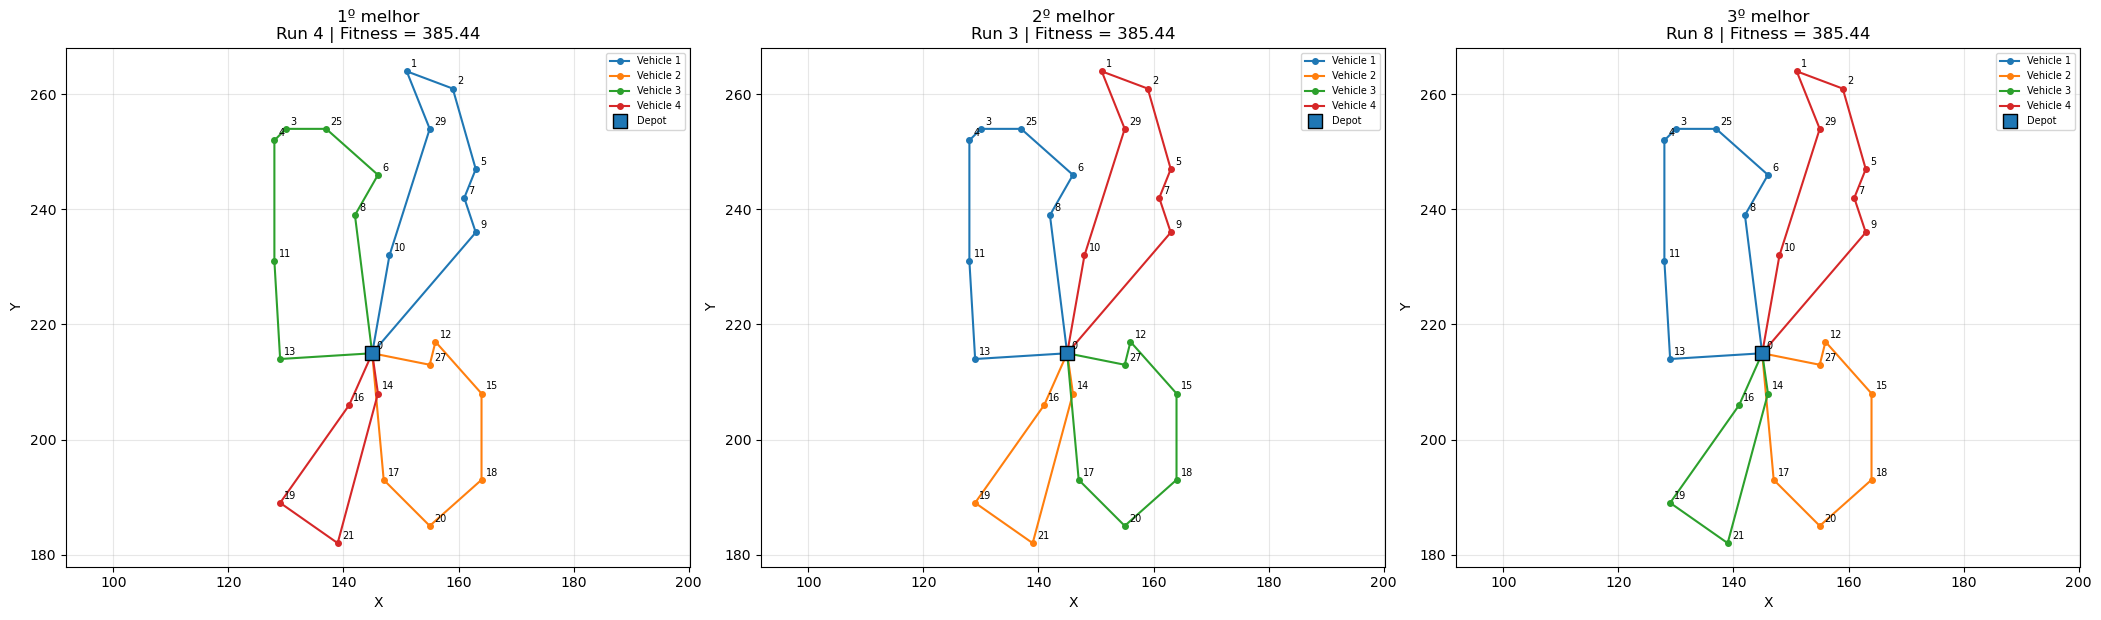


Figure saved at: route_plots/top_3_routes_E-n22-k4.png


In [99]:
# Create output directory
os.makedirs("route_plots", exist_ok=True)


# Process each instance stored in results
for instance_name, instance_results in results.items():

    # ---------------------------------------------------------
    # 1. Find the best parameter combination for this instance
    # ---------------------------------------------------------

    best_key = min(
        instance_results,
        key=lambda key: instance_results[key]["mean_fit"]
    )

    best_result = instance_results[best_key]

    print("\n====================================================")
    print(f"Instance: {instance_name}")
    print("====================================================")

    print("\nBest parameter combination:")
    print(f"mtr: {best_result['mtr']}")
    print(f"cor: {best_result['cor']}")
    print(f"mtm: {best_result['mtm']}")
    print(f"stp: {best_result['stp']}")
    print(f"pop: {best_result['pop']}")

    print(f"\nMean fitness: {best_result['mean_fit']:.6f}")
    print(f"Std fitness:  {best_result['std_fit']:.6f}")
    print(f"Min fitness:  {best_result['min_fit']:.6f}")
    print(f"Max fitness:  {best_result['max_fit']:.6f}")

    # ---------------------------------------------------------
    # 2. Get the three best runs of this parameter combination
    # ---------------------------------------------------------

    best_indices = best_result["best_routes"]

    print("\nThree best runs:")

    for rank, run_index in enumerate(best_indices, start=1):

        print(
            f"{rank}º | "
            f"Run: {run_index + 1} | "
            f"Fitness: {best_result['r_fit'][run_index]:.6f}"
        )

    # ---------------------------------------------------------
    # 3. Find the EVRP instance file
    # ---------------------------------------------------------

    instance_files = glob.glob(
        os.path.join("**", instance_name),
        recursive=True
    )

    if len(instance_files) == 0:

        print(
            f"Instance file not found: {instance_name}"
        )

        continue

    instance_file = instance_files[0]

    # ---------------------------------------------------------
    # 4. Read coordinates from the instance file
    # ---------------------------------------------------------

    coordinates = {}

    reading_coordinates = False

    with open(instance_file, "r", encoding="utf-8") as file:

        for raw_line in file:

            line = raw_line.strip()

            if line == "":
                continue

            if line.upper() == "NODE_COORD_SECTION":

                reading_coordinates = True
                continue

            if reading_coordinates:

                # Stop when the next section starts
                if (
                    line.upper().endswith("_SECTION")
                    or line.upper() == "EOF"
                ):
                    break

                parts = line.split()

                if len(parts) >= 3:

                    node = int(float(parts[0]))
                    x = float(parts[1])
                    y = float(parts[2])

                    coordinates[node] = (x, y)

    if len(coordinates) == 0:

        print(
            f"No coordinates found for: {instance_name}"
        )

        continue

    # ---------------------------------------------------------
    # 5. Create one figure for this instance
    # ---------------------------------------------------------

    figure, axes = plt.subplots(
        1,
        3,
        figsize=(21, 7)
    )

    # ---------------------------------------------------------
    # 6. Plot the three best routes
    # ---------------------------------------------------------

    for plot_index, run_index in enumerate(best_indices):

        axis = axes[plot_index]

        route = best_result["routes"][run_index]

        fitness = best_result["r_fit"][run_index]

        # -----------------------------------------------------
        # Detect node numbering offset
        #
        # C++ routes usually start at 0 while EVRP files
        # usually start node numbering at 1.
        # -----------------------------------------------------

        direct_matches = sum(
            node in coordinates
            for node in route
        )

        shifted_matches = sum(
            node + 1 in coordinates
            for node in route
        )

        if shifted_matches > direct_matches:
            coordinate_offset = 1
        else:
            coordinate_offset = 0

        # -----------------------------------------------------
        # Split the complete route into vehicle routes
        # -----------------------------------------------------

        vehicle_routes = []

        current_route = []

        for node in route:

            current_route.append(node)

            # Depot separates vehicle routes
            if node == 0 and len(current_route) > 1:

                vehicle_routes.append(
                    current_route
                )

                current_route = [0]

        # Save an unfinished final route if necessary
        if len(current_route) > 1:

            vehicle_routes.append(
                current_route
            )

        # -----------------------------------------------------
        # Plot each vehicle route
        # -----------------------------------------------------

        for vehicle_index, vehicle_route in enumerate(
            vehicle_routes
        ):

            x_values = []
            y_values = []

            for node in vehicle_route:

                coordinate_node = (
                    node + coordinate_offset
                )

                if coordinate_node in coordinates:

                    x, y = coordinates[
                        coordinate_node
                    ]

                    x_values.append(x)
                    y_values.append(y)

            axis.plot(
                x_values,
                y_values,
                marker="o",
                markersize=4,
                linewidth=1.5,
                label=f"Vehicle {vehicle_index + 1}"
            )

        # -----------------------------------------------------
        # Add node numbers
        # -----------------------------------------------------

        for node in set(route):

            coordinate_node = (
                node + coordinate_offset
            )

            if coordinate_node in coordinates:

                x, y = coordinates[
                    coordinate_node
                ]

                axis.annotate(
                    str(node),
                    (x, y),
                    xytext=(3, 3),
                    textcoords="offset points",
                    fontsize=7
                )

        # -----------------------------------------------------
        # Highlight depot
        # -----------------------------------------------------

        depot_node = coordinate_offset

        if depot_node in coordinates:

            depot_x, depot_y = coordinates[
                depot_node
            ]

            axis.scatter(
                depot_x,
                depot_y,
                marker="s",
                s=100,
                edgecolors="black",
                zorder=10,
                label="Depot"
            )

        # -----------------------------------------------------
        # Plot formatting
        # -----------------------------------------------------

        axis.set_title(
            f"{plot_index + 1}º melhor\n"
            f"Run {run_index + 1} | "
            f"Fitness = {fitness:.2f}"
        )

        axis.set_xlabel("X")
        axis.set_ylabel("Y")

        axis.grid(
            True,
            alpha=0.3
        )

        axis.axis("equal")

        axis.legend(
            fontsize=7
        )

    # ---------------------------------------------------------
    # 7. Figure title with the selected parameter combination
    # ---------------------------------------------------------

    figure.tight_layout(
        rect=[0, 0, 1, 0.90]
    )

    # ---------------------------------------------------------
    # 8. Save figure
    # ---------------------------------------------------------

    output_name = instance_name.replace(
        ".evrp",
        ""
    )

    output_file = os.path.join(
        "route_plots",
        f"top_3_routes_{output_name}.png"
    )

    figure.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"\nFigure saved at: {output_file}"
    )


INSTANCE: E-n76-k7.evrp
1º combination | Mean fitness = 830.6014
2º combination | Mean fitness = 830.6014
3º combination | Mean fitness = 865.7887


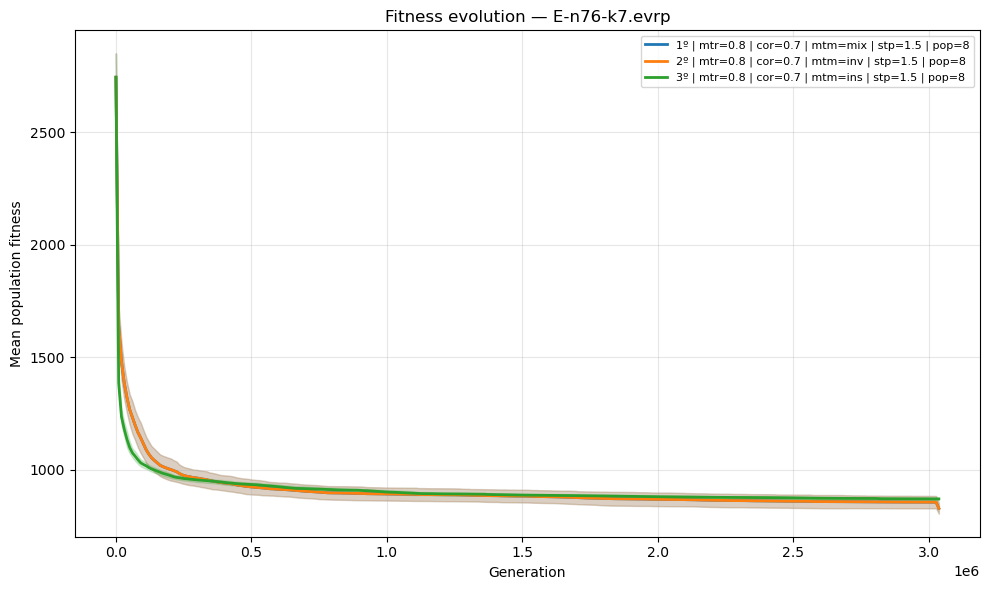

Figure saved at: evolution_plots/fitness_curves_E-n76-k7.png

INSTANCE: E-n22-k4.evrp
1º combination | Mean fitness = 389.0598
2º combination | Mean fitness = 389.0598
3º combination | Mean fitness = 398.0157


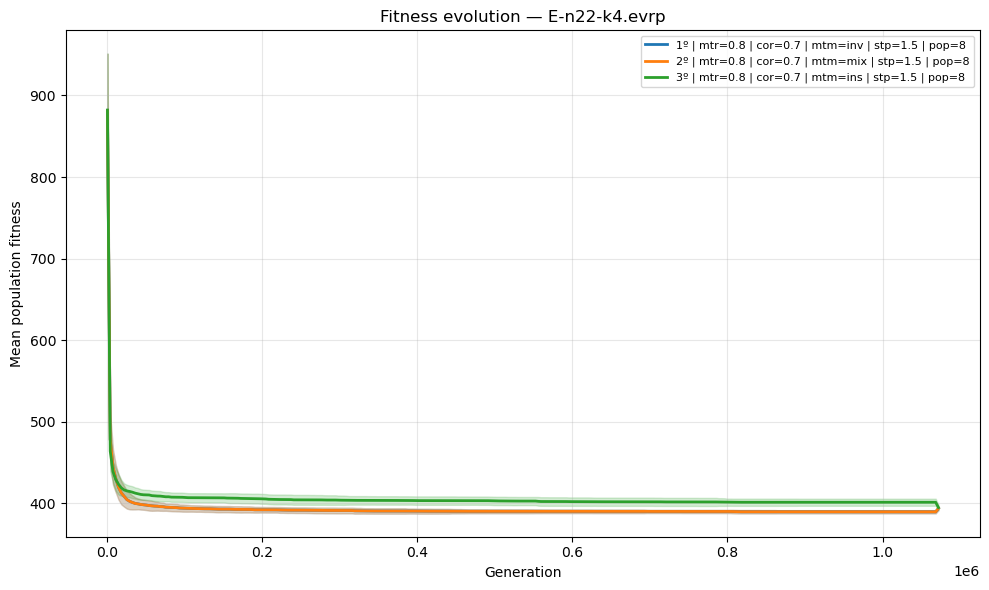

Figure saved at: evolution_plots/fitness_curves_E-n22-k4.png


In [105]:

def load_evolution_curve(curve_file):

    # Read CSV and ignore spaces after commas
    df = pd.read_csv(
        curve_file,
        skipinitialspace=True
    )

    # Group all runs by generation
    curve_df = (
        df.groupby(
            "generation",
            as_index=False
        )
        .agg(
            fit_mean=("fit_mean", "mean"),
            fit_std=("fit_std", "mean")
        )
    )

    return curve_df


# Create output folder
os.makedirs(
    "evolution_plots",
    exist_ok=True
)


# Process each instance separately
for instance_name, instance_results in results.items():

    # ---------------------------------------------------------
    # Select the three best parameter combinations
    # ---------------------------------------------------------

    sorted_combinations = sorted(
        instance_results.items(),
        key=lambda item: item[1]["mean_fit"]
    )

    top_three = sorted_combinations[:3]


    print("\n========================================")
    print(f"INSTANCE: {instance_name}")
    print("========================================")


    # ---------------------------------------------------------
    # Create figure
    # ---------------------------------------------------------

    plt.figure(
        figsize=(10, 6)
    )


    # ---------------------------------------------------------
    # Plot the three best combinations
    # ---------------------------------------------------------

    for rank, (combination_id, data) in enumerate(
        top_three,
        start=1
    ):

        # Evolution curve has the same name as the stats file
        curve_file = os.path.join(
            "evolution_curves",
            f"{data['file_name']}.csv"
        )


        if not os.path.exists(curve_file):

            print(
                f"Curve file not found: {curve_file}"
            )

            continue


        # -----------------------------------------------------
        # Read evolution curve
        # -----------------------------------------------------

        curve_df = load_evolution_curve(
            curve_file
        )


        generations = curve_df[
            "generation"
        ].values

        mean_values = curve_df[
            "fit_mean"
        ].values

        std_values = curve_df[
            "fit_std"
        ].values


        # -----------------------------------------------------
        # Reduce to approximately 300 points
        # -----------------------------------------------------

        n_plot_points = 300

        if len(generations) > n_plot_points:

            plot_indices = np.linspace(
                0,
                len(generations) - 1,
                n_plot_points,
                dtype=int
            )

            generations = generations[
                plot_indices
            ]

            mean_values = mean_values[
                plot_indices
            ]

            std_values = std_values[
                plot_indices
            ]


        # -----------------------------------------------------
        # Curve label
        # -----------------------------------------------------

        label = (
            f"{rank}º | "
            f"mtr={data['mtr']} | "
            f"cor={data['cor']} | "
            f"mtm={data['mtm']} | "
            f"stp={data['stp']} | "
            f"pop={data['pop']}"
        )


        # -----------------------------------------------------
        # Plot mean fitness
        # -----------------------------------------------------

        line, = plt.plot(
            generations,
            mean_values,
            linewidth=2,
            label=label
        )


        # -----------------------------------------------------
        # Plot standard deviation
        # -----------------------------------------------------

        plt.fill_between(
            generations,
            mean_values - std_values,
            mean_values + std_values,
            alpha=0.20,
            color=line.get_color()
        )


        print(
            f"{rank}º combination | "
            f"Mean fitness = {data['mean_fit']:.4f}"
        )


    # ---------------------------------------------------------
    # Plot formatting
    # ---------------------------------------------------------

    plt.title(
        f"Fitness evolution — {instance_name}"
    )

    plt.xlabel(
        "Generation"
    )

    plt.ylabel(
        "Mean population fitness"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend(
        fontsize=8
    )

    plt.tight_layout()


    # ---------------------------------------------------------
    # Save figure
    # ---------------------------------------------------------

    output_name = instance_name.replace(
        ".evrp",
        ""
    )

    output_file = os.path.join(
        "evolution_plots",
        f"fitness_curves_{output_name}.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    print(
        f"Figure saved at: {output_file}"
    )

In [111]:
import os
import pandas as pd


# Create folder for the tables
os.makedirs(
    "tables",
    exist_ok=True
)


# Process each instance separately
for instance_name, instance_results in results.items():

    # --------------------------------------------------------
    # Sort configurations by mean fitness
    # --------------------------------------------------------

    sorted_combinations = sorted(
        instance_results.items(),
        key=lambda item: item[1]["mean_fit"]
    )

    # Select the five best configurations
    top_five = sorted_combinations[:5]

    table_data = []

    # --------------------------------------------------------
    # Create table rows
    # --------------------------------------------------------

    for rank, (combination_id, data) in enumerate(
        top_five,
        start=1
    ):

        table_data.append(
            {
                "rank": rank,

                "mtr": data["mtr"],
                "cor": data["cor"],
                "mtm": data["mtm"],
                "stp": data["stp"],
                "pop": data["pop"],

                "mean_fitness": data["mean_fit"],
                "std_fitness": data["std_fit"],
                "max_fitness": data["max_fit"],
                "min_fitness": data["min_fit"],

                "viable_pct": data["viable_pct"],

                "U": data["mann_whitney_U"],
                "p_value": data["p_value"],
                "p_adjusted": data["p_adjusted"],

                "result": data["statistical_result"]
            }
        )

    # --------------------------------------------------------
    # Create DataFrame
    # --------------------------------------------------------

    instance_df = pd.DataFrame(
        table_data
    )

    # --------------------------------------------------------
    # Round values
    # --------------------------------------------------------

    instance_df["mean_fitness"] = (
        instance_df["mean_fitness"].round(3)
    )

    instance_df["std_fitness"] = (
        instance_df["std_fitness"].round(3)
    )

    instance_df["max_fitness"] = (
        instance_df["max_fitness"].round(3)
    )

    instance_df["min_fitness"] = (
        instance_df["min_fitness"].round(3)
    )

    instance_df["viable_pct"] = (
        instance_df["viable_pct"].round(2)
    )

    # --------------------------------------------------------
    # Display table
    # --------------------------------------------------------

    print("\n========================================")
    print(f"INSTANCE: {instance_name}")
    print("========================================")

    display(
        instance_df
    )

    # --------------------------------------------------------
    # Save CSV
    # --------------------------------------------------------

    output_name = instance_name.replace(
        ".evrp",
        ""
    )

    output_file = os.path.join(
        "tables",
        f"top_5_{output_name}.csv"
    )

    instance_df.to_csv(
        output_file,
        index=False
    )

    print(
        f"CSV saved as: {output_file}"
    )


INSTANCE: E-n76-k7.evrp


,rank,mtr,cor,mtm,stp,pop,mean_fitness,std_fitness,max_fitness,min_fitness,viable_pct,U,p_value,p_adjusted,result
0,1,0.8,0.7,mix,1.5,8,830.601,46.784,922.541,764.483,100.0,NaN,NaN,NaN,Best configuration
1,2,0.8,0.7,inv,1.5,8,830.601,46.784,922.541,764.483,100.0,200.0,1.000000,1.000000,No significant difference
2,3,0.8,0.7,ins,1.5,8,865.789,51.407,962.723,754.459,100.0,278.0,0.036048,0.108145,No significant difference
3,4,0.8,0.7,swp,1.5,8,939.513,61.650,1088.577,859.720,100.0,371.0,0.000004,0.000012,Statistically worse


CSV saved as: tables/top_5_E-n76-k7.csv

INSTANCE: E-n22-k4.evrp


,rank,mtr,cor,mtm,stp,pop,mean_fitness,std_fitness,max_fitness,min_fitness,viable_pct,U,p_value,p_adjusted,result
0,1,0.8,0.7,inv,1.5,8,389.060,5.813,404.841,385.442,100.0,NaN,NaN,NaN,Best configuration
1,2,0.8,0.7,mix,1.5,8,389.060,5.813,404.841,385.442,100.0,200.0,1.000000,1.000000,No significant difference
2,3,0.8,0.7,ins,1.5,8,398.016,11.063,425.748,385.442,100.0,318.5,0.001156,0.003469,Statistically worse
3,4,0.8,0.7,swp,1.5,8,408.921,14.255,435.894,385.442,100.0,364.0,0.000007,0.000020,Statistically worse


CSV saved as: tables/top_5_E-n22-k4.csv
